In [28]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

Comparing different control efforts related to an adaptive coupling constant, against that of a fixed constant

Case 1 - adapting based on the current phase difference $\varphi = (\theta_j - \theta_i)$

[inf, np.float64(11.07964766145484), np.float64(11.015415085875944), np.float64(10.056796979080469), np.float64(8.95038707958178), np.float64(7.933053723559411), np.float64(7.056047900174301), np.float64(6.311531675375225), np.float64(5.679679412336717), np.float64(5.154108021255464), np.float64(5.1542946007490915), np.float64(5.679208065360797), np.float64(6.3109454602204), np.float64(7.056962497877826), np.float64(7.934653484624727), np.float64(8.95114030222683), np.float64(10.058591248923907), np.float64(11.017846550237461), np.float64(11.082123722731923), inf]


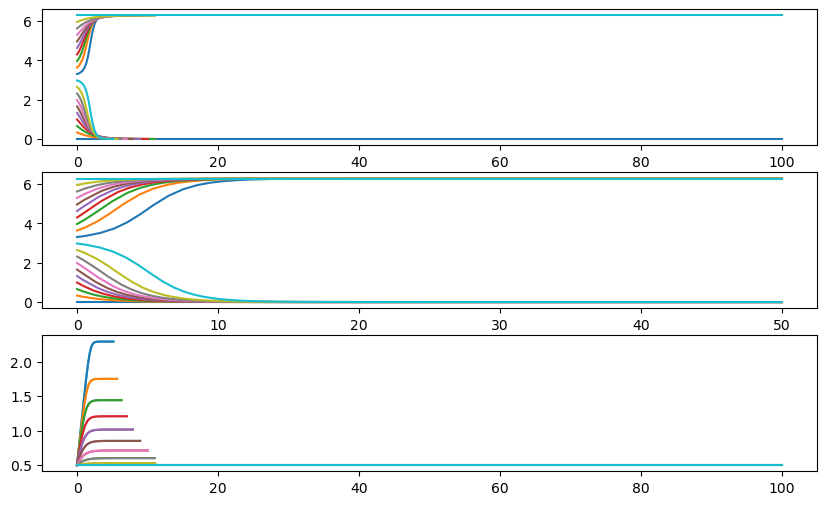

In [29]:
def rhs_updates(t,y,omega,eta):
    
    delta = y[0]
    kappa = y[1]


    dphi_dt = omega - kappa*np.sin(delta)
    dkappa_dt = eta*(1 - np.cos(delta))

    return [dphi_dt,dkappa_dt]

def phi_dot(t,y,omega): 

    phi = y[0]
    K = y[1]

    return [omega - K * np.sin(phi),0]


def steady(t,y,omega,eta):
    delta = (y[0] % (2*np.pi))
    threshold = 1e-3
    return min(abs(delta),abs(delta - 2*np.pi)) - threshold

steady.terminal = True
#steady.direction = -1

init_phi = np.linspace(0,2*np.pi,20)
init_K = 0.5    

center = 4 * np.pi
spread = 0.5
w1 = np.random.uniform(center - spread, center + spread)
w2 = np.random.uniform(center - spread, center + spread)
omega = 0
critical = abs(omega)


eta = 0.5

fig,axs = plt.subplots(3,1,figsize=(10,6))

sync_times = []
for phi0 in init_phi:
    sol_adaptive = solve_ivp(rhs_updates,[0,100],[phi0,init_K],args=(omega,eta),rtol=1e-6,events=steady)
    axs[0].plot(sol_adaptive.t,sol_adaptive.y[0])
    axs[2].plot(sol_adaptive.t,sol_adaptive.y[1])

    if len(sol_adaptive.t_events[0]) > 0:
        sync_times.append(sol_adaptive.t_events[0][0])
    else:
        sync_times.append(np.inf)
print(sync_times)

for phi0 in init_phi:
    sol_fixed = solve_ivp(phi_dot,[0,50],[phi0,init_K],args=(omega,),rtol=1e-6)
    axs[1].plot(sol_fixed.t,sol_fixed.y[0])

#np trapz can solve these

#also consider time to sync, or required control effort against start positions

[np.float64(81.97840552141545), np.float64(14.262060103804185), np.float64(11.221796100286412), np.float64(9.775747535806122), np.float64(8.523727806579224), np.float64(7.360826890501048), np.float64(6.532175121940839), np.float64(5.942833971044313), np.float64(4.946614435603086), np.float64(4.667883715660027), np.float64(4.449750687689149), np.float64(4.281134158622859), np.float64(4.137046579687533), np.float64(4.012306994109933), np.float64(3.8986728895444287), np.float64(3.799213976071316), np.float64(3.711270662255398), np.float64(3.6306894040761777), np.float64(3.5567681602672114), np.float64(3.4891427452584227)]


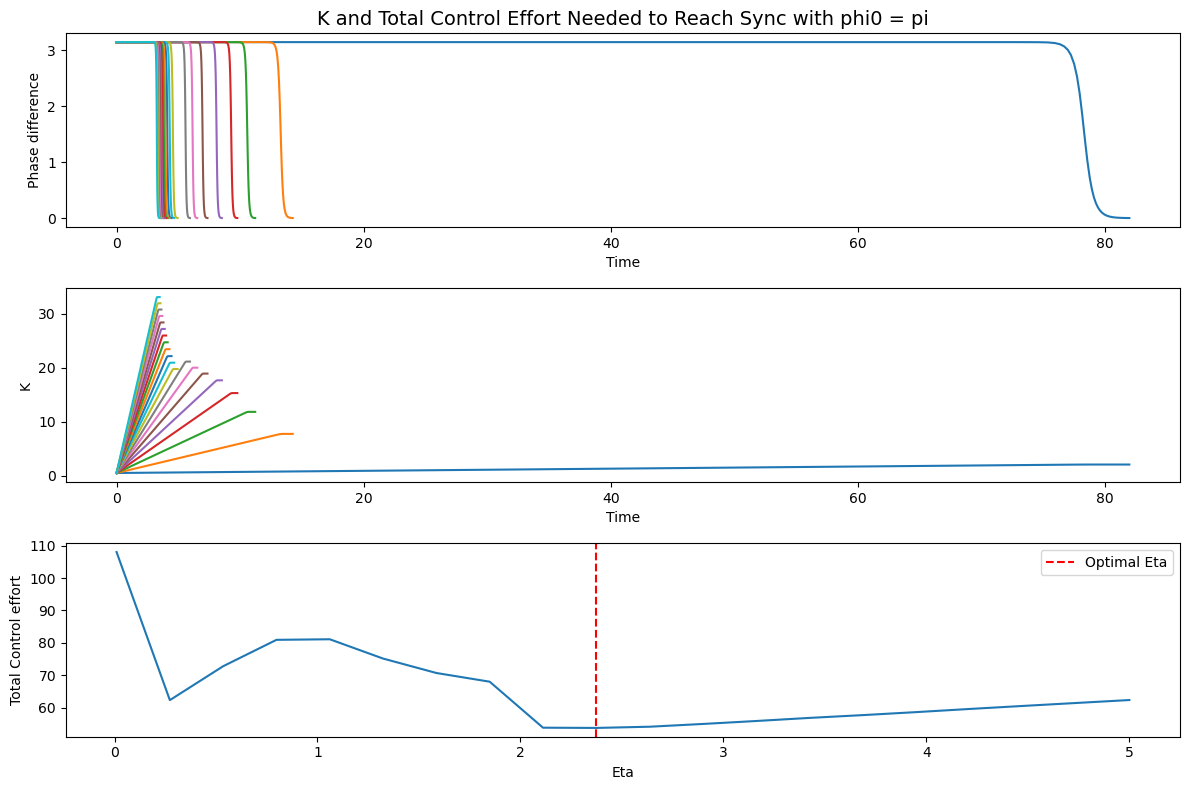

In [30]:
eta_list = np.linspace(0.01,5,20)
costs = []
synctimes = []

omega = 0
phi0 = np.pi

fig,axs = plt.subplots(3,1,figsize=(12,8))

for eta in eta_list:
    sol_adaptive = solve_ivp(rhs_updates,[0,100],[phi0,init_K],args=(omega,eta),rtol=1e-6,events=steady)
    axs[0].plot(sol_adaptive.t,sol_adaptive.y[0])
    axs[1].plot(sol_adaptive.t,sol_adaptive.y[1])

    axs[1].set_xlabel('Time')
    axs[0].set_xlabel('Time')
    axs[0].set_ylabel('Phase difference')
    axs[1].set_ylabel('K')
    axs[2].set_ylabel('Total Control effort')
    axs[2].set_xlabel('Eta')

    if len(sol_adaptive.t_events[0]) > 0:
        synctimes.append(sol_adaptive.t_events[0][0])
    else:
        synctimes.append(0)

    costs.append(np.trapezoid(sol_adaptive.y[1],sol_adaptive.t))
axs[2].plot(eta_list,costs)
axs[0].set_title('K and Total Control Effort Needed to Reach Sync with phi0 = pi',fontsize=14)
print(synctimes)
plt.tight_layout()

optimal_eta = eta_list[np.argmin(costs)]
axs[2].axvline(optimal_eta,c='r',linestyle='--',label='Optimal Eta')
axs[2].legend()

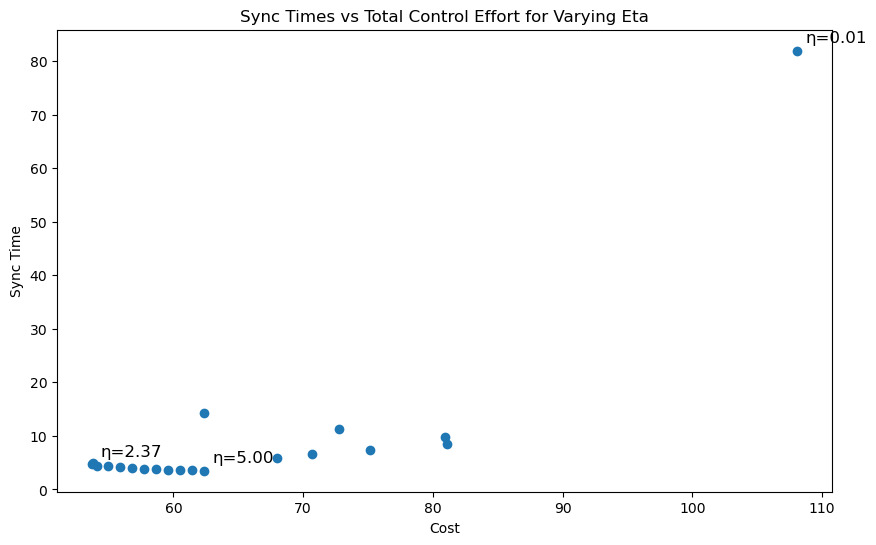

In [31]:
plt.figure(figsize=(10,6))
plt.scatter(costs,synctimes)
plt.title('Sync Times vs Total Control Effort for Varying Eta')
plt.xlabel('Cost')
plt.ylabel('Sync Time')

key_indices = [np.argmin(costs), np.argmin(synctimes), np.argmax(costs)]

for i in key_indices:
    plt.annotate(f'η={eta_list[i]:.2f}', 
                 (costs[i], synctimes[i]),
                 textcoords="offset points",
                 xytext=(6,6),
                 fontsize=12)

Adapting based on phase coherence $r(t)$, maybe avg phase after if makes sense.

Using the $N_{oscillators} \rightarrow \infty$ case

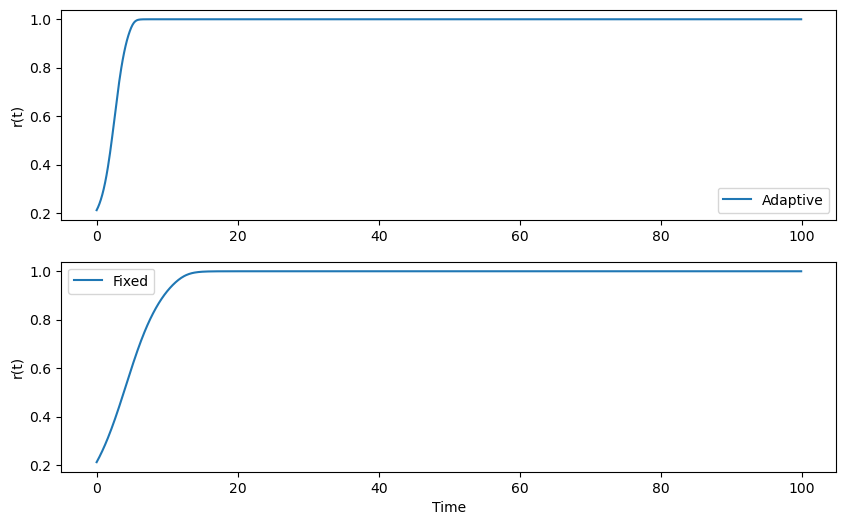

In [32]:
N = 100

omega = np.zeros(N)#np.random.randn(N)
K = 0.5
theta = np.random.uniform(0,2*np.pi,N)

omega_init = omega.copy()
theta_init = theta.copy()

dt = 0.1
time = np.arange(0,100,dt)

r_history_adaptive = np.zeros(len(time))
sols = []

eta = 0.5

fig,axs = plt.subplots(2,1,figsize=(10,6))
K_adaptive = []


for idx,t in enumerate(time):
 
    z = np.mean(np.exp(1j*theta_init))
    r = np.abs(z)
    psi = np.angle(z)

    r_history_adaptive[idx] = r

    K += eta*(1 - r)*dt
    K_adaptive.append(K)

    theta_dot = omega_init + K*r*np.sin(psi - theta_init)
    sols.append(theta_dot)
    theta_init += theta_dot * dt

axs[0].plot(time,r_history_adaptive,label='Adaptive')
axs[0].set_ylabel('r(t)')
axs[0].legend()

r_history = np.zeros(len(time))

K = 0.5
omega_init = omega.copy()
theta_init = theta.copy()



for idx,t in enumerate(time):
 
    z = np.mean(np.exp(1j*theta_init))
    r = np.abs(z)
    psi = np.angle(z)

    r_history[idx] = r

    theta_dot = omega_init + K*r*np.sin(psi - theta_init)
    sols.append(theta_dot)
    theta_init += theta_dot * dt

axs[1].plot(time,r_history,label='Fixed')
axs[1].set_ylabel('r(t)')
axs[1].set_xlabel('Time')
axs[1].legend()

np.float64(153.95128123284252)

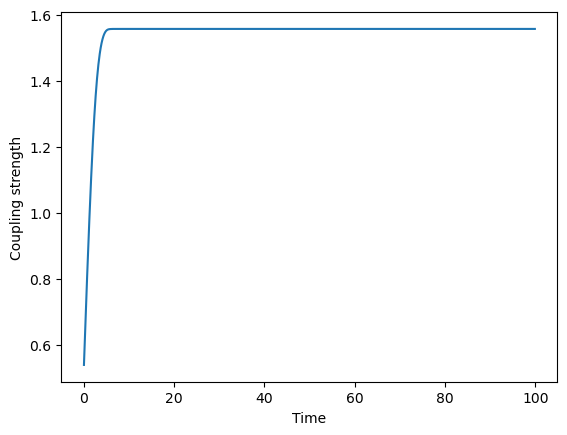

In [33]:
plt.plot(time,K_adaptive)
plt.xlabel('Time')
plt.ylabel('Coupling strength')

np.trapezoid(K_adaptive,time) #tot control effort

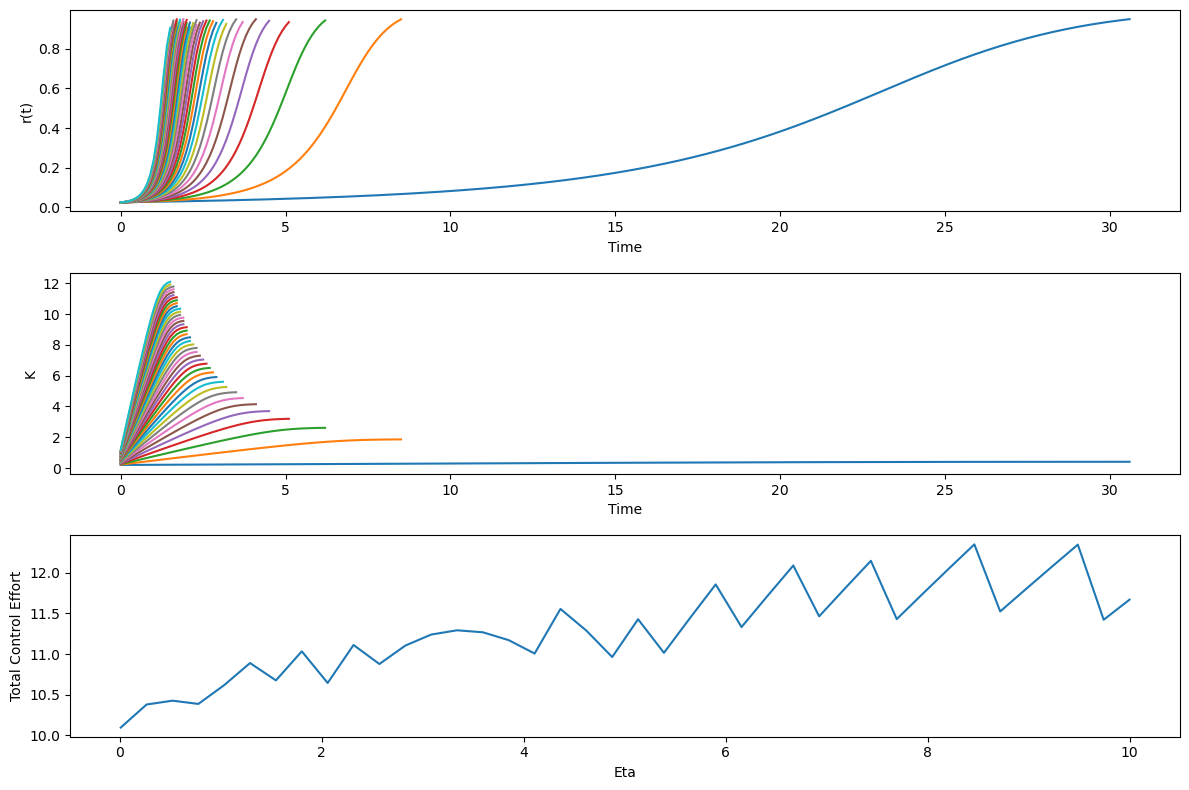

In [ ]:
N = 1000
omega = np.zeros(N)
omega_init = omega.copy()

dt = 0.1
time = np.arange(0,100,dt)

fig,axs = plt.subplots(3,1,figsize=(12,8))

eta_list = np.linspace(0.01,10,40)
r_thresh = 0.95

totalcosts = []
synctimes = []

np.random.seed(42)
theta_fixed = np.random.uniform(0,2*np.pi,N)
#theta = np.array([0]*(N//2) + [np.pi + 0.1]*(N//2))

for eta in eta_list:
    K = 0.2
    theta_init = theta_fixed.copy()
    r_history_adaptive = np.zeros(len(time))
    K_adaptive = []
    for idx,t in enumerate(time):
    
        z = np.mean(np.exp(1j*theta_init))
        r = np.abs(z)
        psi = np.angle(z)

        r_history_adaptive[idx] = r

        if r >= r_thresh:
            synctimes.append(t)
            break

        K += eta*(1 - r)*dt
        K_adaptive.append(K)

        theta_dot = omega_init + K*r*np.sin(psi - theta_init)
        theta_init += theta_dot * dt
    
    totalcosts.append(np.trapezoid(K_adaptive,time[:len(K_adaptive)]))


    axs[0].plot(time[:idx],r_history_adaptive[:idx],label='Adaptive')
    axs[1].plot(time[:len(K_adaptive)],K_adaptive)

axs[0].set_title('')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('r(t)')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('K')

axs[2].plot(eta_list,totalcosts)
axs[2].set_xlabel('Eta')
axs[2].set_ylabel('Total Control Effort')
plt.tight_layout()

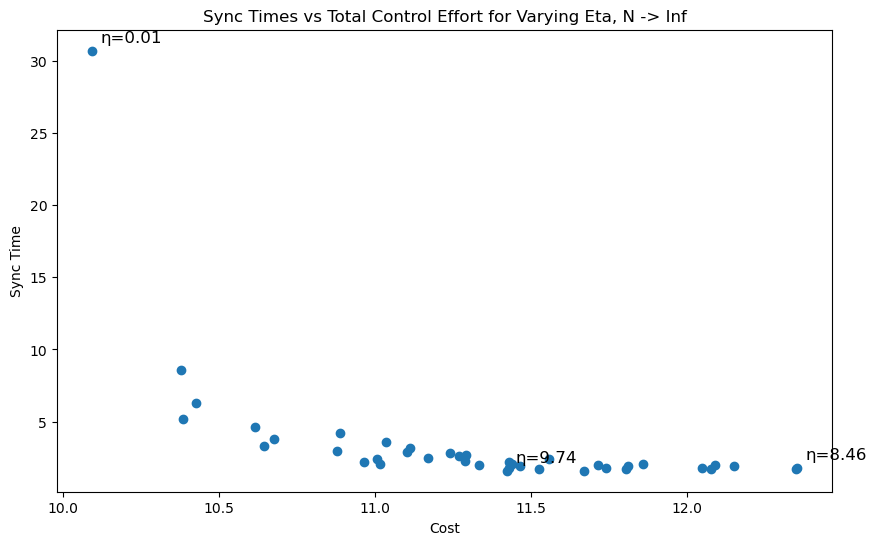

In [54]:
plt.figure(figsize=(10,6))
plt.scatter(totalcosts,synctimes)

plt.title('Sync Times vs Total Control Effort for Varying Eta, N -> Inf')
plt.xlabel('Cost')
plt.ylabel('Sync Time')

key_indices = [np.argmin(totalcosts), np.argmin(synctimes), np.argmax(totalcosts)]

for i in key_indices:
    plt.annotate(f'η={eta_list[i]:.2f}', 
                 (totalcosts[i], synctimes[i]),
                 textcoords="offset points",
                 xytext=(6,6),
                 fontsize=12)